In [1]:
import os,sys
os.environ['USE_PYGEOS'] = '0'

import geopandas as gpd
# import pygeos
# import pyproj
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
# from shapely import LineString, Point, Polygon
# import shapely

parent_dir = Path().resolve().parent
sys.path.insert(0, str(os.path.join(parent_dir,'src')))
from utils import *

In [2]:
# Import landuse sites
landuse_sites = gpd.read_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_osm_boundary.gpkg')
landuse_sites_gdf = gpd.GeoDataFrame(landuse_sites, geometry='geometry', crs='EPSG:4326')
landuse_sites_gdf = landuse_sites_gdf.to_crs(epsg=32648)
print(len(landuse_sites_gdf))

# Import industries
industries_df = gpd.read_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/intersected_polygons.gpkg')
industries_gdf = gpd.GeoDataFrame(industries_df, geometry='geometry', crs='EPSG:4326')
industries_gdf = industries_gdf.rename(columns={'Unnamed: 0': 'industry_id', 'name_1': 'name'})
industries_gdf = industries_gdf.to_crs(epsg=32648)
# industries_gdf['area'] = industries_gdf['geometry'].apply(lambda geom: geom.area)
industries_gdf['geometry'] = industries_gdf['geometry'].apply(convert_to_point)
industries_gdf = industries_gdf[industries_gdf['business_status'] == 'OPERATIONAL']

# Import nodes_gdftations from table_nodes_500m.gpkg
nodes_gdf =  gpd.read_file("../outputs/table_nodes_200m_update_remove_disconnected.gpkg")

# Import electricity demand statistics
sector_demand_df = pd.read_excel('../data/sectors_searchstrings_full.xlsx')

2064


In [3]:
# operational_industries_gdf = industries_gdf[industries_gdf['business_status'] == 'OPERATIONAL']
# print(len(operational_industries_gdf))
# nonoperational_industries_gdf = industries_gdf[~industries_gdf.index.isin(operational_industries_gdf.index)]
# print(len(nonoperational_industries_gdf))
# nonoperational_industries_gdf.head()

In [5]:
# print(nodes_gdf['capacity'].sum()*0.54)
# print(len(industries_gdf))
# print(nodes_gdf['capacity'].sum()*0.54 / len(industries_gdf))

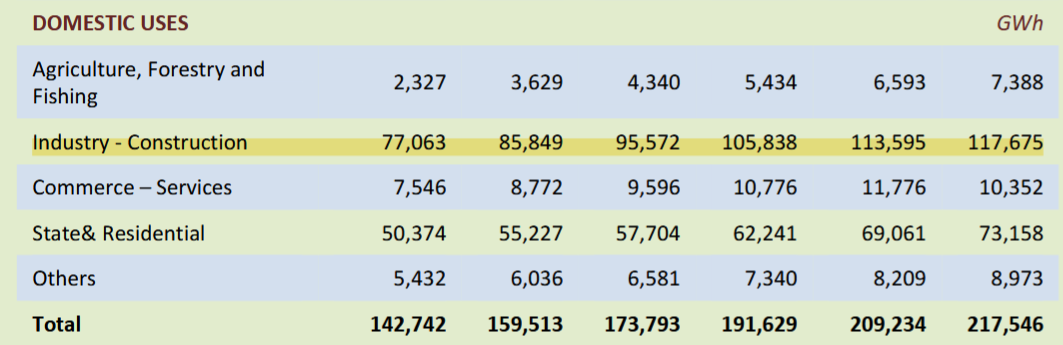
industries_gdf['required_capacity'] = nodes_gdf['Capacity'].sum()***0.54** / len(industries_gdf)

**0.54** represents the proportion of industrial use in the total electricity: 117675/217546=0.54.

In [4]:
# Step 1: Count the number of each Sector_id in industries_gdf
sector_counts = industries_gdf.groupby('Sector_id').size()
print(sector_counts)

# Step 2: Distribute the total electricity_demand in sector_demand_df to each industry_id under each Sector_id
# Create a mapping from sector_id to total_demand
sector_demand_dict = sector_demand_df.set_index('sector_id')['electricity_demand'].to_dict()

# Step 3: Add electricity_demand and required_capacity to industries_gdf
# The total electricity demand for each Sector_id / the number of industries under that Sector_id, to get the electricity demand for each industry_id
industries_gdf['electricity_demand'] = industries_gdf['Sector_id'].map(sector_demand_dict) / industries_gdf['Sector_id'].map(sector_counts)
# industries_gdf['required_capacity'] = nodes_gdf['capacity'].sum() * 0.54 / len(industries_gdf)

# Step 4: Sum the electricity_demand and required_capacity, respectively,
# for all industries_gdf records with the same osmid, and assign it to the corresponding osmid in landuse_sites_gdf
# Aggregate the electricity_demand of all industries in industries_gdf by osmid
aggregated_demand = industries_gdf.groupby('osmid')['electricity_demand'].sum().rename('total_electricity_demand')
# aggregated_capacity = industries_gdf.groupby('osmid')['required_capacity'].sum().rename('total_required_capacity')

# Merge the aggregated results into landuse_sites_gdf
landuse_sites_gdf = landuse_sites_gdf.merge(aggregated_demand, how='left', left_on='osmid', right_index=True)
# landuse_sites_gdf = landuse_sites_gdf.merge(aggregated_capacity, how='left', left_on='osmid', right_index=True)
print(len(landuse_sites_gdf))
landuse_sites_gdf_cleaned = landuse_sites_gdf.dropna(subset=['total_electricity_demand'])
print(len(landuse_sites_gdf_cleaned))

Sector_id
1     621
2     349
3     120
4     347
5     122
6     596
7     708
8     589
9     166
10    746
11    717
12    593
13    651
14    399
dtype: int64
2064
1378


In [5]:
def assign_buses_to_loads_with_k(landuse_sites_gdf, nodes_gdf, p=0.8): #, distance_threshold=60000
    nodes_gdf = nodes_gdf.copy().set_index('NodeID')
    results_dict = {}
    # # need to set the distance_threshold larger than 60 km to ensure all landuse sites have corresponding substations????????????????????
    # distance_threshold = 60000

    # Iterate through each landuse site
    for idx, landuse_site in landuse_sites_gdf.iterrows():
        landuse_site_id = landuse_site['osmid']
        distances = nodes_gdf.geometry.distance(landuse_site.geometry)  # Calculate the distance to each substation

        # Initialize the dictionary for the current landuse site
        results_dict[landuse_site_id] = {}
        norm_probs = {}
        
        # Sort the substations by distance to the landuse site (ascending)
        sorted_idx = np.argsort(distances.values)  # 获取距离的排序索引
        
        sum_weighted_prob = 0
        weighted_probs = {}
        capacities = {}
        P_ks = {}

        # Calculate raw weights for all substations
        for k, sub_idx in enumerate(sorted_idx, start=1):
            distance = distances.iloc[sub_idx]
            # if distance <= distance_threshold:  # Exclude distances greater than threshold
            sub_id = nodes_gdf.index[sub_idx]
            # capacity = nodes_gdf.at[sub_id, 'capacity']
            capacity = nodes_gdf.at[sub_id, 'sn_mva']
            capacities[sub_id] = capacity

            P_k = p * (1 - p) ** (k - 1)   # 几何概率
            P_ks[sub_id] = P_k
            weighted_prob = capacity * P_k  # 计算原始权重
            weighted_probs[sub_id] = weighted_prob
            sum_weighted_prob += weighted_prob
        
        # Assign normalized weights to each substation
        for sub_id, weighted_prob in weighted_probs.items():
            # if distance <= distance_threshold:  # Exclude distances of 0 and those exceeding the threshold
            norm_prob = weighted_prob / sum_weighted_prob  # Calculate normalized weight
            norm_probs[sub_id] = norm_prob

            distance = distances.loc[sub_id]

            # Save the detailed information of the substation
            results_dict[landuse_site_id][sub_id] = {
                'norm_prob': norm_probs[sub_id],
                'weighted_probs': weighted_prob,
                'P_k': P_ks[sub_id],  #weighted_probs[sub_id] / capacity,  # Store P_k for the specific substation,
                'distance': distance,  # Add the distance inf
            }

        # Calculate the cumulative distribution function (CDF)
        cdf = {}
        cumulative_sum = 0
        for sub_id, norm_prob in norm_probs.items():
            cumulative_sum += norm_prob
            cdf[sub_id] = cumulative_sum

        # Generate a random number between 0 and 1
        random_seed = np.random.random()

        # Determine the substation based on the random number and CDF
        selected_substation = None
        for sub_id, cdf_value in cdf.items():
            if random_seed <= cdf_value:
                selected_substation = sub_id
                break

        # Assign the selected substation to the BusID of the landuse site
        if selected_substation is not None:
            landuse_sites_gdf.loc[landuse_sites_gdf['osmid'] == landuse_site_id, 'BusID'] = selected_substation

    # Return the updated landuse_sites_gdf with the assigned BusID (if needed)
    return results_dict, landuse_sites_gdf

In [6]:
results_dict, landuse_sites_gdf_add_bus = assign_buses_to_loads_with_k(landuse_sites_gdf_cleaned, nodes_gdf)

/scistor/ivm/mye500/miniconda3/envs/py311/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
# # Calculate the average hourly power consumption (MW)
# # There are 24*365=8760 hours in a year
# # Estimate peak demand (assumed to be 1.5 times the annual consumption)
# landuse_sites_gdf_add_bus['peak_demand_MW'] = landuse_sites_gdf_add_bus['total_electricity_demand'] * 1000 / 8760 # * 1.5

In [10]:
# print("Total electricity sales: ", sum(landuse_sites_gdf_add_bus['total_electricity_demand']), "GWh")
# # print("Total capacity: ", sum(landuse_sites_gdf_add_bus['total_required_capacity']))
# print("Total demand: ", sum(landuse_sites_gdf_add_bus['peak_demand_MW']), "MW")

In [14]:
landuse_sites_gdf_add_bus.to_excel('../outputs/landuse_sites_gdf_add_bus.xlsx', index=False)
landuse_sites_gdf_add_bus.to_file('../outputs/landuse_sites_gdf_add_bus.gpkg', driver='GPKG')

In [12]:
print(len(landuse_sites_gdf_cleaned))
print(len(landuse_sites_gdf_add_bus))

1378
1378


In [32]:
# sum(landuse_sites_gdf_add_bus['peak_demand_MW'])

In [33]:
# # Initialize the minimum distance as None
# min_distance = None

# # Iterate through each landuse site
# for landuse_site_id, subs_info in results_dict.items():
#     # Iterate through each substation
#     for sub_id, info in subs_info.items():
#         distance = info['distance']
        
#         # Update the minimum distance
#         if min_distance is None or distance < min_distance:
#             min_distance = distance

# # Output the minimum distance
# if min_distance is not None:
#     print("All distances' minimum value:", min_distance)
# else:
#     print("No distances found.")

In [7]:
def get_top_subs(results_dict, landuse_site_id):
    # Get all substation information for the given landuse site
    if landuse_site_id in results_dict:
        # Sort substation information by weight and take the top 1000???????????
        top_subs = sorted(results_dict[landuse_site_id].items(), key=lambda item: item[1]['norm_prob'], reverse=True)[:10]

        output = []
        for sub_id, info in top_subs:
            output.append({
                'sub_id': sub_id,
                'distance': info['distance'],
                # 'capacity': info['capacity'],
                'norm_prob': info['norm_prob'],
                'P_k': info['P_k'],
                # 'weighted_prob': info['weighted_prob']
                })
        return pd.DataFrame(output)
        
    else:
        print(f"Landuse site ID '{landuse_site_id}' not found in results_dict.")
        return None

In [8]:
get_top_subs(results_dict, 876508089)

,sub_id,distance,norm_prob,P_k
0,NODEVN3590,3078.039610,7.690893e-01,8.000000e-01
1,NODEVN1729,16494.353022,2.050905e-01,1.600000e-01
2,NODEVN3607,18379.910522,2.050905e-02,3.200000e-02
3,NODEVN2881,20717.458982,4.101810e-03,6.400000e-03
4,NODEVN3589,20910.419401,8.203619e-04,1.280000e-03
5,NODEVN1764,21938.747940,3.281448e-04,2.560000e-04
6,NODEVN2671,23207.797836,3.281448e-05,5.120000e-05
7,NODEVN1731,24628.136440,2.625158e-05,1.024000e-05
8,NODEVN1730,27001.365592,1.050063e-06,4.096000e-07
9,NODEVN3876,25050.013287,6.562895e-07,2.048000e-06


In [9]:
top_subs_dict = {}

# Iterate through each landuse_site_id in results_dict and calculate its top_subs
for landuse_site_id in results_dict:
    top_subs_df = get_top_subs(results_dict, landuse_site_id)
    if top_subs_df is not None:
        # Convert top_subs_df to a dictionary and store it in top_subs_dict
        top_subs_dict[landuse_site_id] = top_subs_df.to_dict(orient='records')

In [10]:
top_subs_dict[876508089]

[{'sub_id': 'NODEVN3590',
  'distance': 3078.039609985892,
  'norm_prob': 0.7690893054743233,
  'P_k': 0.8},
 {'sub_id': 'NODEVN1729',
  'distance': 16494.353021629446,
  'norm_prob': 0.20509048145981948,
  'P_k': 0.15999999999999998},
 {'sub_id': 'NODEVN3607',
  'distance': 18379.910521695867,
  'norm_prob': 0.020509048145981944,
  'P_k': 0.03199999999999999},
 {'sub_id': 'NODEVN2881',
  'distance': 20717.458982201202,
  'norm_prob': 0.004101809629196388,
  'P_k': 0.006399999999999996},
 {'sub_id': 'NODEVN3589',
  'distance': 20910.41940079577,
  'norm_prob': 0.0008203619258392775,
  'P_k': 0.001279999999999999},
 {'sub_id': 'NODEVN1764',
  'distance': 21938.747940074838,
  'norm_prob': 0.00032814477033571085,
  'P_k': 0.0002559999999999997},
 {'sub_id': 'NODEVN2671',
  'distance': 23207.797836102825,
  'norm_prob': 3.281447703357108e-05,
  'P_k': 5.119999999999994e-05},
 {'sub_id': 'NODEVN1731',
  'distance': 24628.13643981975,
  'norm_prob': 2.625158162685686e-05,
  'P_k': 1.0239999

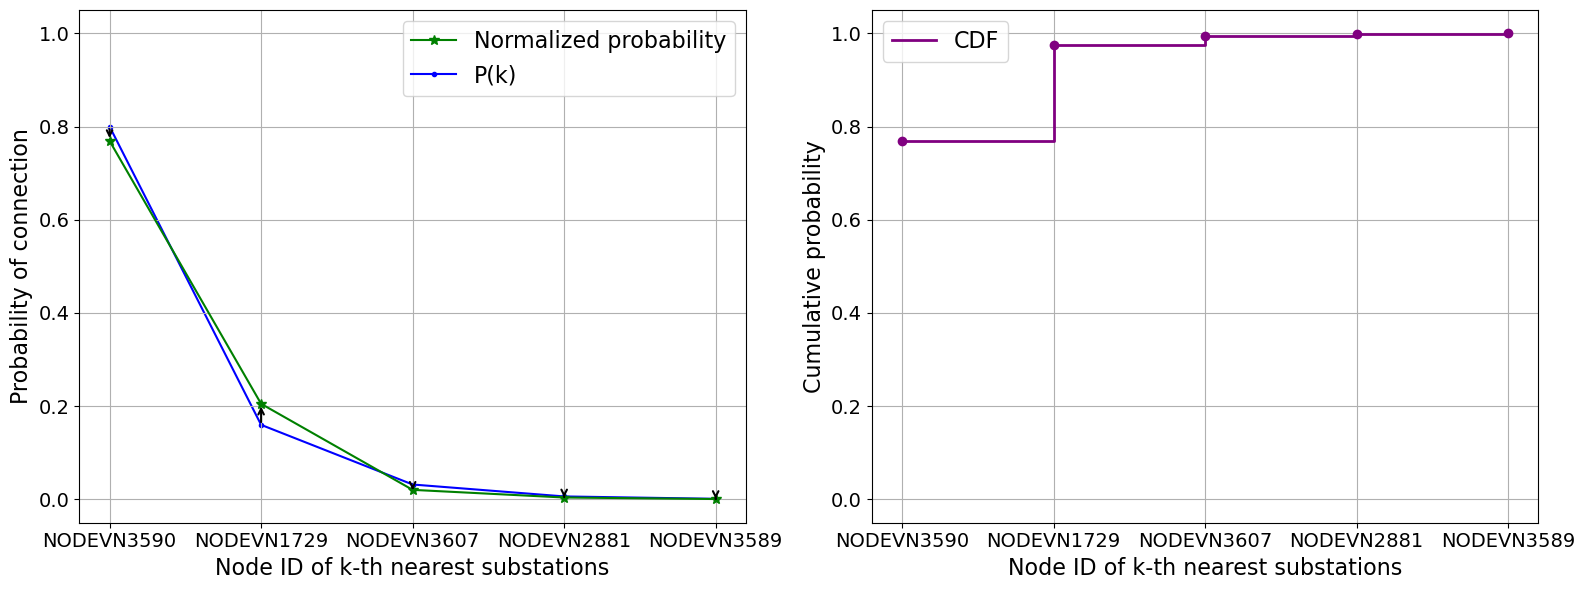

In [11]:
landuse_site = results_dict[876508089]

# Extract the data for the top 5 substations
top_items = sorted(landuse_site.items(), key=lambda item: item[1]['norm_prob'], reverse=True)[:5]

osm_ids = [str(sub_id) for sub_id, _ in top_items]  # x 轴：OSM ID
norm_probs_sorted = [data['norm_prob'] for _, data in top_items]
P_ks_sorted = [data['P_k'] for _, data in top_items]

# Calculate the CDF for the top 5 substations
cdf_values = [sum(norm_probs_sorted[:i+1]) for i in range(len(norm_probs_sorted))]

# Create a single figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plotting the first graph: Normalized Probability and P(k) with arrows
ax[0].plot(osm_ids, norm_probs_sorted, marker='*', linestyle='-', color='green', zorder=2, markersize=7, label='Normalized probability')
ax[0].plot(osm_ids, P_ks_sorted, marker='o', linestyle='-', color='blue', zorder=1, markersize=3, label='P(k)')

# Add arrows to the first plot
for i, (pk, norm) in enumerate(zip(P_ks_sorted, norm_probs_sorted)):
    ax[0].annotate(
        '', xy=(i, norm), xytext=(i, pk),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
    )
# ax[0].set_title('Landuse site 876508089')
ax[0].set_xlabel('Node ID of k-th nearest substations', fontsize=16)
ax[0].set_ylabel('Probability of connection', fontsize=16)
ax[0].grid(True)
ax[0].legend(fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].set_ylim(-0.05, 1.05)  # 让 y 轴从 0 开始，到略高于 1

# Plotting the second graph: CDF
ax[1].step(range(1, len(norm_probs_sorted)+1), cdf_values, where='post', color='purple', linewidth=2, label='CDF')
# ax[1].fill_between(range(1, len(norm_probs_sorted)+1), 0, cdf_values, color='purple', alpha=0.3)
ax[1].plot(range(1, len(norm_probs_sorted)+1), cdf_values, 'o', color='purple')  # 添加点（可选）

# ax[1].set_title('CDF for Top 5 Substations (by norm_prob)', fontsize=13)
ax[1].set_xlabel('Node ID of k-th nearest substations', fontsize=16)
ax[1].set_ylabel('Cumulative probability', fontsize=16)
ax[1].grid(True)
ax[1].set_xticks(range(1, len(norm_probs_sorted)+1))
ax[1].set_xticklabels([sub_id for sub_id, _ in top_items], fontsize=14)
ax[1].legend(fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].set_ylim(-0.05, 1.05)  # 让 y 轴从 0 开始，到略高于 1

plt.tight_layout()

fig.savefig('../figures/Fig_S3_top5_sub_connection_prob.png', dpi=800, bbox_inches='tight')
fig.savefig('../figures/Fig_S3_top5_sub_connection_prob.svg', bbox_inches='tight')

plt.show()


In [22]:
# Calculate the sum of normalized probabilities
norm_probs = [value['norm_prob'] for value in landuse_site.values()]
total_norm_prob = sum(norm_probs)
total_norm_prob

1.0000000000000002

——————————————————————————————————

IGNORE BELOW

In [32]:
nodes_gdf_new = nodes_gdf.copy()
landuse_sites_gdf_add_bus_new = landuse_sites_gdf_add_bus.copy()
landuse_sites_gdf_add_bus_new['BusID']=None
print(landuse_sites_gdf_add_bus_new)

# Iterate through each landuse_site_id in top_subs_dict
for landuse_site_id, subs_info in top_subs_dict.items():
    if subs_info:  # Ensure subs_info is not empty
        required_capacity = landuse_sites_gdf_add_bus_new.loc[
            landuse_sites_gdf_add_bus_new['osmid'] == landuse_site_id, 'total_required_capacity'
            ].values[0]
        
        subs_info_sorted = sorted(subs_info, key=lambda x: x['weight'], reverse=True)
        matched = False  # Flag to check if a match is found

        for sub in subs_info_sorted:
            sub_id = sub['sub_id']
            sub_capacity = nodes_gdf_new.loc[nodes_gdf_new['NodeID'] == sub_id, 'capacity'].values[0]
            
            if required_capacity <= sub_capacity:
                # Update the BusID column in landuse_sites_gdf_add_bus
                landuse_sites_gdf_add_bus_new.loc[landuse_sites_gdf_add_bus_new['osmid'] == landuse_site_id, 'BusID'] = sub_id

                # Subtract the required_capacity of the landuse_site
                nodes_gdf_new.loc[nodes_gdf_new['NodeID'] == sub_id, 'capacity'] -= int(required_capacity)
                matched = True  # Found a match

        if not matched:
            # Check if BusID is still None
            current_busid = landuse_sites_gdf_add_bus_new.loc[
                landuse_sites_gdf_add_bus_new['osmid'] == landuse_site_id, 'BusID'
            ].values[0]
            
            if current_busid is None or pd.isna(current_busid):
                print(f"No suitable substation found for landuse site {landuse_site_id} with required capacity {required_capacity}.")

landuse_sites_gdf_add_bus_new.head()

     element_type       osmid  \
0             way   876508089   
1             way   876286185   
4             way   876286186   
7             way   876508090   
8             way   876286177   
...           ...         ...   
2050          way   761293346   
2052          way   761293350   
2054          way  1222693356   
2055          way   469655719   
2058          way  1118344033   

                                                  nodes     landuse  \
0     [8157751794, 8157751793, 8157751792, 815775179...  industrial   
1     [8155710983, 8155710982, 8155710981, 815571098...  industrial   
4     [8155710990, 8155710989, 8155710988, 815571098...  industrial   
7     [8157751806, 8157751805, 8157751804, 815775180...  industrial   
8     [8155707958, 8155707957, 8155707956, 815570795...  industrial   
...                                                 ...         ...   
2050  [7112684915, 7112684943, 7112684944, 711268494...  industrial   
2052  [7112684966, 7112684967, 7112

,element_type,osmid,nodes,landuse,name,name:en,operator,owner,plant:method,plant:output:electricity,...,addr:hamlet,port:type,ruins,addr:district:en,addr:province:en,addr:subdistrict:en,geometry,total_electricity_demand,total_required_capacity,BusID
0,way,876508089,"[8157751794, 8157751793, 8157751792, 815775179...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,"POLYGON ((521908.382 994781.312, 521831.348 99...",34.098949,5815.864267,NODEVN1731
1,way,876286185,"[8155710983, 8155710982, 8155710981, 815571098...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,"POLYGON ((517082.121 1012145.562, 517013.27 10...",34.098949,5815.864267,NODEVN3359a
4,way,876286186,"[8155710990, 8155710989, 8155710988, 815571098...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,"POLYGON ((516824.904 1012809.168, 516796.548 1...",139.532632,34895.185605,None
7,way,876508090,"[8157751806, 8157751805, 8157751804, 815775180...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,"POLYGON ((531328.127 1014894.974, 531322.497 1...",34.098949,5815.864267,None
8,way,876286177,"[8155707958, 8155707957, 8155707956, 815570795...",industrial,None,None,None,None,None,None,...,None,None,None,None,None,None,"POLYGON ((534591.202 1016328.623, 534639.937 1...",34.098949,5815.864267,None


In [33]:
top_subs_dict[876286186]

[{'sub_id': 'NODEVN3607',
  'distance': 500.8064528823366,
  'weight': 0.8714939886546013},
 {'sub_id': 'NODEVN2880',
  'distance': 4814.954656051502,
  'weight': 0.08714939886546011},
 {'sub_id': 'NODEVN1764',
  'distance': 5542.127571734486,
  'weight': 0.020915855727710417},
 {'sub_id': 'NODEVN4014',
  'distance': 5304.181155006553,
  'weight': 0.017429879773092016},
 {'sub_id': 'NODEVN2671',
  'distance': 8372.368473819392,
  'weight': 0.001394390381847361},
 {'sub_id': 'NODEVN1729',
  'distance': 10042.803965585032,
  'weight': 0.0008366342291084162},
 {'sub_id': 'NODEVN1731',
  'distance': 10253.512438984997,
  'weight': 0.0006135317680128386},
 {'sub_id': 'NODEVN1730',
  'distance': 11182.269007692417,
  'weight': 0.00013386147665734655},
 {'sub_id': 'NODEVN3359b',
  'distance': 11338.464708366186,
  'weight': 2.6772295331469302e-05},
 {'sub_id': 'NODEVN3359a',
  'distance': 11401.14675751342,
  'weight': 5.35445906629386e-06}]

In [34]:
# Ensure NodeID and NodeID types are consistent
# nodes_gdf['Index'] = nodes_gdf['Index'].astype(str)

# Merge the two GeoDataFrames based on NodeID
landuse_sites_gdf_add_bus_new['BusID'] = landuse_sites_gdf_add_bus_new['BusID'].astype(str)
nodes_gdf['NodeID'] = nodes_gdf['NodeID'].astype(str)
data = landuse_sites_gdf_add_bus_new.merge(nodes_gdf, left_on='BusID', right_on='NodeID', how='inner')

# Group by NodeID and summarize
summary = data.groupby('BusID').agg(
    Total_Capacity=('capacity', 'first'),
    Number_of_Connected_Landuse_Sites=('total_required_capacity', 'count'),
    Total_Required_Capacity=('total_required_capacity', 'sum'),
).reset_index()

# Calculate capacity usage percentage
summary['Capacity_Usage_Percent (%)'] = (summary['Total_Required_Capacity'] / summary['Total_Capacity'] * 100).round(2)

summary

,BusID,Total_Capacity,Number_of_Connected_Landuse_Sites,Total_Required_Capacity,Capacity_Usage_Percent (%)
0,NODEVN0003a,36000,1,11631.728535,32.31
1,NODEVN0003b,36000,2,34895.185605,96.93
2,NODEVN0019a,21000,1,11631.728535,55.39
3,NODEVN0020,36000,1,17447.592802,48.47
4,NODEVN0024,36000,1,34895.185605,96.93
...,...,...,...,...,...
375,NODEVN3922a,25800,1,5815.864267,22.54
376,NODEVN3985,24000,4,23263.457070,96.93
377,NODEVN4029,12000,1,5815.864267,48.47
378,NODEVN4032,36000,2,29079.321337,80.78


In [35]:
landuse_sites_gdf_add_bus_new.to_excel('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_gdf_add_bus.xlsx', index=False)
landuse_sites_gdf_add_bus_new.to_file('../../cascading_failure/mapping_industries_economic_sectors/outputs/landuse_sites_gdf_add_bus.gpkg', driver='GPKG')

In [ ]:
landuse_sites_gdf_add_bus_new.crs

<Projected CRS: EPSG:32648>
Name: WGS 84 / UTM zone 48N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°E and 108°E, northern hemisphere between equator and 84°N, onshore and offshore. Cambodia. China. Indonesia. Laos. Malaysia - West Malaysia. Mongolia. Russian Federation. Singapore. Thailand. Vietnam.
- bounds: (102.0, 0.0, 108.0, 84.0)
Coordinate Operation:
- name: UTM zone 48N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich